In [7]:
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


# =====================================
# LOAD MODELS
# =====================================

rf_wesad = joblib.load("wesad_model.pkl")
rf_sleep = joblib.load("sleep_model.pkl")
mlp_fitbit = joblib.load("fitbit_model.pkl")

# =====================================
# LOAD DATA
# =====================================

X_wesad = np.load("X_wesad.npy")
y_wesad = np.load("y_wesad.npy")

X_sleep = np.load("X_sleep.npy")
y_sleep = np.load("y_sleep.npy")

X_fitbit = np.load("X_fitbit.npy")
y_fitbit = np.load("y_fitbit.npy")


# =====================================
# ALIGN DATA
# =====================================

min_samples = min(len(X_wesad), len(X_sleep), len(X_fitbit))

X_w = X_wesad[:min_samples]
X_s = X_sleep[:min_samples]
X_f = X_fitbit[:min_samples]

y_fusion = y_wesad[:min_samples]


# =====================================
# 1️⃣ FEATURE LEVEL FUSION
# =====================================

X_fusion = np.concatenate((X_w, X_s, X_f), axis=1)

scaler = StandardScaler()
X_fusion = scaler.fit_transform(X_fusion)

from sklearn.ensemble import RandomForestClassifier

rf_fusion = RandomForestClassifier(n_estimators=200)
rf_fusion.fit(X_fusion, y_fusion)

fusion_pred = rf_fusion.predict(X_fusion)

print("Early Fusion Accuracy:",
      accuracy_score(y_fusion, fusion_pred))


# =====================================
# 2️⃣ DECISION LEVEL FUSION
# =====================================

prob_wesad = rf_wesad.predict_proba(X_w)[:,1]
prob_sleep = rf_sleep.predict_proba(X_s)[:,1]

pred_fitbit = mlp_fitbit.predict(X_f)
pred_fitbit_norm = (pred_fitbit - pred_fitbit.min()) / (
                    pred_fitbit.max() - pred_fitbit.min())

w1, w2, w3 = 0.4, 0.3, 0.3

fusion_score = (w1 * prob_wesad +
                w2 * prob_sleep +
                w3 * pred_fitbit_norm)

fusion_pred = (fusion_score > 0.5).astype(int)

print("Late Fusion Accuracy:",
      accuracy_score(y_fusion, fusion_pred))


# =====================================
# 3️⃣ STACKING FUSION
# =====================================

meta_features = np.column_stack([
    prob_wesad,
    prob_sleep,
    pred_fitbit_norm
])

meta_model = LogisticRegression()
meta_model.fit(meta_features, y_fusion)




meta_pred = meta_model.predict(meta_features)

print("Stacking Fusion Accuracy:",
      accuracy_score(y_fusion, meta_pred))


Early Fusion Accuracy: 1.0


/Users/deepikabudidhi/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


ValueError: X has 12 features, but MLPRegressor is expecting 5 features as input.

In [1]:
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


# =====================================
# LOAD SAVED MODELS
# =====================================

rf_wesad = joblib.load("wesad_model.pkl")
rf_sleep = joblib.load("sleep_model.pkl")
mlp_fitbit = joblib.load("fitbit_model.pkl")


# =====================================
# LOAD SAVED DATA
# =====================================

X_wesad = np.load("X_wesad.npy")
y_wesad = np.load("y_wesad.npy")

X_sleep = np.load("X_sleep.npy")
y_sleep = np.load("y_sleep.npy")

X_fitbit = np.load("X_fitbit.npy")
y_fitbit = np.load("y_fitbit.npy")


# =====================================
# ALIGN DATA (MINIMUM COMMON SAMPLES)
# =====================================

min_samples = min(len(X_wesad), len(X_sleep), len(X_fitbit))

X_w = X_wesad[:min_samples]
X_s = X_sleep[:min_samples]
X_f = X_fitbit[:min_samples]

y_fusion = y_wesad[:min_samples]


# =====================================
# TRAIN TEST SPLIT (COMMON SPLIT)
# =====================================

X_w_train, X_w_test, y_train, y_test = train_test_split(
    X_w, y_fusion,
    test_size=0.2,
    random_state=42,
    stratify=y_fusion
)

X_s_train, X_s_test, _, _ = train_test_split(
    X_s, y_fusion,
    test_size=0.2,
    random_state=42,
    stratify=y_fusion
)

X_f_train, X_f_test, _, _ = train_test_split(
    X_f, y_fusion,
    test_size=0.2,
    random_state=42,
    stratify=y_fusion
)


# =====================================
# 1️⃣ EARLY FUSION (FEATURE LEVEL)
# =====================================

print("\n========== EARLY FUSION ==========")

# Concatenate features
X_train_fusion = np.concatenate((X_w_train, X_s_train, X_f_train), axis=1)
X_test_fusion = np.concatenate((X_w_test, X_s_test, X_f_test), axis=1)

# Scale correctly (fit only on training)
scaler = StandardScaler()
X_train_fusion = scaler.fit_transform(X_train_fusion)
X_test_fusion = scaler.transform(X_test_fusion)

rf_fusion = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_fusion.fit(X_train_fusion, y_train)

early_pred = rf_fusion.predict(X_test_fusion)

print("Accuracy:", accuracy_score(y_test, early_pred))
print("Precision:", precision_score(y_test, early_pred))
print("Recall:", recall_score(y_test, early_pred))
print("F1 Score:", f1_score(y_test, early_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, early_pred))


# =====================================
# 2️⃣ LATE FUSION (DECISION LEVEL)
# =====================================

print("\n========== LATE FUSION ==========")

prob_wesad = rf_wesad.predict_proba(X_w_test)[:, 1]
prob_sleep = rf_sleep.predict_proba(X_s_test)[:, 1]

pred_fitbit = mlp_fitbit.predict(X_f_test)

# Normalize Fitbit predictions
pred_fitbit_norm = (pred_fitbit - pred_fitbit.min()) / (
    pred_fitbit.max() - pred_fitbit.min() + 1e-8)

# Weighted averaging
w1, w2, w3 = 0.4, 0.3, 0.3

fusion_score = (w1 * prob_wesad +
                w2 * prob_sleep +
                w3 * pred_fitbit_norm)

late_pred = (fusion_score > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, late_pred))
print("Precision:", precision_score(y_test, late_pred))
print("Recall:", recall_score(y_test, late_pred))
print("F1 Score:", f1_score(y_test, late_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, late_pred))


# =====================================
# 3️⃣ STACKING FUSION
# =====================================

print("\n========== STACKING FUSION ==========")

meta_train = np.column_stack([
    rf_wesad.predict_proba(X_w_train)[:, 1],
    rf_sleep.predict_proba(X_s_train)[:, 1],
    mlp_fitbit.predict(X_f_train)
])

meta_test = np.column_stack([
    rf_wesad.predict_proba(X_w_test)[:, 1],
    rf_sleep.predict_proba(X_s_test)[:, 1],
    mlp_fitbit.predict(X_f_test)
])

meta_model = LogisticRegression()
meta_model.fit(meta_train, y_train)

stack_pred = meta_model.predict(meta_test)

print("Accuracy:", accuracy_score(y_test, stack_pred))
print("Precision:", precision_score(y_test, stack_pred))
print("Recall:", recall_score(y_test, stack_pred))
print("F1 Score:", f1_score(y_test, stack_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, stack_pred))


print("\n✅ Fusion evaluation completed successfully.")


========== EARLY FUSION ==========
Accuracy: 0.9946524064171123
Precision: 1.0
Recall: 0.993103448275862
F1 Score: 0.9965397923875432
Confusion Matrix:
 [[ 42   0]
 [  1 144]]

========== LATE FUSION ==========
Accuracy: 0.22459893048128343
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:
 [[ 42   0]
 [145   0]]

========== STACKING FUSION ==========


/Users/deepikabudidhi/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.7807486631016043
Precision: 0.7795698924731183
Recall: 1.0
F1 Score: 0.8761329305135952
Confusion Matrix:
 [[  1  41]
 [  0 145]]

✅ Fusion evaluation completed successfully.


In [2]:
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


# =====================================
# LOAD MODELS
# =====================================

rf_wesad = joblib.load("wesad_model.pkl")
rf_sleep = joblib.load("sleep_model.pkl")
mlp_fitbit = joblib.load("fitbit_model.pkl")


# =====================================
# LOAD DATA
# =====================================

X_wesad = np.load("X_wesad.npy")
y_wesad = np.load("y_wesad.npy")

X_sleep = np.load("X_sleep.npy")
y_sleep = np.load("y_sleep.npy")

X_fitbit = np.load("X_fitbit.npy")
y_fitbit = np.load("y_fitbit.npy")


# =====================================
# ALIGN DATA
# =====================================

min_samples = min(len(X_wesad), len(X_sleep), len(X_fitbit))

X_w = X_wesad[:min_samples]
X_s = X_sleep[:min_samples]
X_f = X_fitbit[:min_samples]

y_fusion = y_wesad[:min_samples]


# =====================================
# COMMON TRAIN TEST SPLIT
# =====================================

X_w_train, X_w_test, y_train, y_test = train_test_split(
    X_w, y_fusion,
    test_size=0.2,
    random_state=42,
    stratify=y_fusion
)

X_s_train, X_s_test, _, _ = train_test_split(
    X_s, y_fusion,
    test_size=0.2,
    random_state=42,
    stratify=y_fusion
)

X_f_train, X_f_test, _, _ = train_test_split(
    X_f, y_fusion,
    test_size=0.2,
    random_state=42,
    stratify=y_fusion
)


# =====================================
# 1️⃣ EARLY FUSION
# =====================================

print("\n========== EARLY FUSION ==========")

X_train_fusion = np.concatenate((X_w_train, X_s_train, X_f_train), axis=1)
X_test_fusion = np.concatenate((X_w_test, X_s_test, X_f_test), axis=1)

scaler = StandardScaler()
X_train_fusion = scaler.fit_transform(X_train_fusion)
X_test_fusion = scaler.transform(X_test_fusion)

rf_fusion = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_fusion.fit(X_train_fusion, y_train)

early_pred = rf_fusion.predict(X_test_fusion)
early_prob = rf_fusion.predict_proba(X_test_fusion)[:, 1]

print("Accuracy:", accuracy_score(y_test, early_pred))
print("Precision:", precision_score(y_test, early_pred))
print("Recall:", recall_score(y_test, early_pred))
print("F1 Score:", f1_score(y_test, early_pred))
print("ROC-AUC:", roc_auc_score(y_test, early_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, early_pred))
print("\nClassification Report:\n",
      classification_report(y_test, early_pred))


# =====================================
# 2️⃣ LATE FUSION (OPTIMAL THRESHOLD)
# =====================================

print("\n========== LATE FUSION ==========")

prob_wesad = rf_wesad.predict_proba(X_w_test)[:, 1]
prob_sleep = rf_sleep.predict_proba(X_s_test)[:, 1]

pred_fitbit = mlp_fitbit.predict(X_f_test)
pred_fitbit_norm = (pred_fitbit - pred_fitbit.min()) / (
    pred_fitbit.max() - pred_fitbit.min() + 1e-8)

# Weighted fusion
fusion_score = (0.4 * prob_wesad +
                0.3 * prob_sleep +
                0.3 * pred_fitbit_norm)

# Optimal threshold using ROC
fpr, tpr, thresholds = roc_curve(y_test, fusion_score)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

late_pred = (fusion_score > optimal_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, late_pred))
print("Precision:", precision_score(y_test, late_pred))
print("Recall:", recall_score(y_test, late_pred))
print("F1 Score:", f1_score(y_test, late_pred))
print("ROC-AUC:", roc_auc_score(y_test, fusion_score))
print("Confusion Matrix:\n", confusion_matrix(y_test, late_pred))
print("\nClassification Report:\n",
      classification_report(y_test, late_pred))


# =====================================
# 3️⃣ STACKING FUSION
# =====================================

print("\n========== STACKING FUSION ==========")

meta_train = np.column_stack([
    rf_wesad.predict_proba(X_w_train)[:, 1],
    rf_sleep.predict_proba(X_s_train)[:, 1],
    mlp_fitbit.predict(X_f_train)
])

meta_test = np.column_stack([
    rf_wesad.predict_proba(X_w_test)[:, 1],
    rf_sleep.predict_proba(X_s_test)[:, 1],
    mlp_fitbit.predict(X_f_test)
])

meta_model = LogisticRegression(class_weight='balanced')
meta_model.fit(meta_train, y_train)

stack_pred = meta_model.predict(meta_test)
stack_prob = meta_model.predict_proba(meta_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, stack_pred))
print("Precision:", precision_score(y_test, stack_pred))
print("Recall:", recall_score(y_test, stack_pred))
print("F1 Score:", f1_score(y_test, stack_pred))
print("ROC-AUC:", roc_auc_score(y_test, stack_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, stack_pred))
print("\nClassification Report:\n",
      classification_report(y_test, stack_pred))


print("\n✅ Fusion evaluation completed successfully.")


========== EARLY FUSION ==========
Accuracy: 0.9946524064171123
Precision: 1.0
Recall: 0.993103448275862
F1 Score: 0.9965397923875432
ROC-AUC: 0.999671592775041
Confusion Matrix:
 [[ 42   0]
 [  1 144]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        42
           1       1.00      0.99      1.00       145

    accuracy                           0.99       187
   macro avg       0.99      1.00      0.99       187
weighted avg       0.99      0.99      0.99       187


========== LATE FUSION ==========
Accuracy: 0.9625668449197861
Precision: 0.9928571428571429
Recall: 0.9586206896551724
F1 Score: 0.9754385964912281
ROC-AUC: 0.9683087027914614
Confusion Matrix:
 [[ 41   1]
 [  6 139]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92        42
           1       0.99      0.96      0.98       145

    accuracy                       

In [10]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# ==========================================================
# 1️⃣ LOAD RAW FEATURE ARRAYS
# ==========================================================

X_wesad = np.load("X_wesad.npy")
y_wesad = np.load("y_wesad.npy")

X_sleep = np.load("X_sleep.npy")
y_sleep = np.load("y_sleep.npy")

X_fitbit = np.load("X_fitbit.npy")
y_fitbit = np.load("y_fitbit.npy")


# ==========================================================
# 2️⃣ ALIGN DATA (ENSURE SAME SAMPLE SIZE)
# ==========================================================

min_samples = min(len(X_wesad), len(X_sleep), len(X_fitbit))

X_w = X_wesad[:min_samples]
X_s = X_sleep[:min_samples]
X_f = X_fitbit[:min_samples]

# Use ONE consistent label (must be same task)
y = y_wesad[:min_samples]


# ==========================================================
# 3️⃣ TRAIN–TEST SPLIT (CRITICAL STEP)
# ==========================================================

indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split each modality using SAME indices
X_w_train, X_w_test = X_w[train_idx], X_w[test_idx]
X_s_train, X_s_test = X_s[train_idx], X_s[test_idx]
X_f_train, X_f_test = X_f[train_idx], X_f[test_idx]

y_train, y_test = y[train_idx], y[test_idx]


# ==========================================================
# 4️⃣ SCALE FEATURES (FIT ONLY ON TRAIN DATA)
# ==========================================================

scaler_w = StandardScaler()
scaler_s = StandardScaler()
scaler_f = StandardScaler()

X_w_train = scaler_w.fit_transform(X_w_train)
X_w_test = scaler_w.transform(X_w_test)

X_s_train = scaler_s.fit_transform(X_s_train)
X_s_test = scaler_s.transform(X_s_test)

X_f_train = scaler_f.fit_transform(X_f_train)
X_f_test = scaler_f.transform(X_f_test)


# ==========================================================
# 5️⃣ TRAIN BASE MODELS (NO DATA LEAKAGE)
# ==========================================================

rf_wesad = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,              # limit tree depth
    min_samples_split=5,      # avoid splitting small nodes
    min_samples_leaf=3,       # minimum samples per leaf
    class_weight='balanced',
    random_state=42
)
rf_wesad.fit(X_w_train, y_train)


rf_sleep = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,              # limit tree depth
    min_samples_split=5,      # avoid splitting small nodes
    min_samples_leaf=3,       # minimum samples per leaf
    class_weight='balanced',
    random_state=42
)
rf_sleep.fit(X_s_train, y_train)


mlp_fitbit = MLPClassifier(
    hidden_layer_sizes=(32,),  # smaller network
    alpha=0.01,                # L2 regularization
    max_iter=300,
    random_state=42
)
mlp_fitbit.fit(X_f_train, y_train)


# ==========================================================
# 6️⃣ CREATE META FEATURES (STACKING)
# ==========================================================

meta_train = np.column_stack([
    rf_wesad.predict_proba(X_w_train)[:, 1],
    rf_sleep.predict_proba(X_s_train)[:, 1],
    mlp_fitbit.predict_proba(X_f_train)[:, 1]
])

meta_test = np.column_stack([
    rf_wesad.predict_proba(X_w_test)[:, 1],
    rf_sleep.predict_proba(X_s_test)[:, 1],
    mlp_fitbit.predict_proba(X_f_test)[:, 1]
])


# ==========================================================
# 7️⃣ TRAIN META MODEL
# ==========================================================

meta_model = LogisticRegression(class_weight='balanced')
meta_model.fit(meta_train, y_train)

stack_pred = meta_model.predict(meta_test)
stack_prob = meta_model.predict_proba(meta_test)[:, 1]


# ==========================================================
# 8️⃣ FINAL EVALUATION
# ==========================================================

print("\n========== FINAL LEAK-FREE STACKING FUSION ==========\n")

print("Accuracy:", accuracy_score(y_test, stack_pred))
print("Precision:", precision_score(y_test, stack_pred, zero_division=0))
print("Recall:", recall_score(y_test, stack_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, stack_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, stack_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, stack_pred))

print("\nClassification Report:\n",
      classification_report(y_test, stack_pred))

print("\n✅ Pipeline completed successfully — No data leakage.")



========== FINAL LEAK-FREE STACKING FUSION ==========

Accuracy: 0.9893617021276596
Precision: 1.0
Recall: 0.9863013698630136
F1 Score: 0.993103448275862
ROC-AUC: 0.9978799739073712

Confusion Matrix:
 [[ 42   0]
 [  2 144]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        42
           1       1.00      0.99      0.99       146

    accuracy                           0.99       188
   macro avg       0.98      0.99      0.98       188
weighted avg       0.99      0.99      0.99       188


✅ Pipeline completed successfully — No data leakage.


/Users/deepikabudidhi/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [11]:
# Train-test split (already correct)
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_w_train, X_w_test = X_w[train_idx], X_w[test_idx]
X_s_train, X_s_test = X_s[train_idx], X_s[test_idx]
X_f_train, X_f_test = X_f[train_idx], X_f[test_idx]

y_train, y_test = y[train_idx], y[test_idx]


In [12]:
# ==========================================
# EARLY FUSION
# ==========================================

# Combine features horizontally
X_train_early = np.concatenate(
    (X_w_train, X_s_train, X_f_train),
    axis=1
)

X_test_early = np.concatenate(
    (X_w_test, X_s_test, X_f_test),
    axis=1
)

# Train single classifier
early_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,              # limit tree depth
    min_samples_split=5,      # avoid splitting small nodes
    min_samples_leaf=3,       # minimum samples per leaf
    class_weight='balanced',
    random_state=42
)

early_model.fit(X_train_early, y_train)

early_pred = early_model.predict(X_test_early)
early_prob = early_model.predict_proba(X_test_early)[:, 1]

print("\n========== EARLY FUSION ==========")
print("Accuracy:", accuracy_score(y_test, early_pred))
print("F1 Score:", f1_score(y_test, early_pred))
print("ROC-AUC:", roc_auc_score(y_test, early_prob))



========== EARLY FUSION ==========
Accuracy: 0.9946808510638298
F1 Score: 0.9965635738831615
ROC-AUC: 0.9993476842791911


In [13]:
# ==========================================
# LATE FUSION (Soft Voting)
# ==========================================

# Get probabilities from each base model
prob_w = rf_wesad.predict_proba(X_w_test)[:, 1]
prob_s = rf_sleep.predict_proba(X_s_test)[:, 1]
prob_f = mlp_fitbit.predict_proba(X_f_test)[:, 1]

# Simple average (soft voting)
late_prob = (prob_w + prob_s + prob_f) / 3

late_pred = (late_prob > 0.5).astype(int)

print("\n========== LATE FUSION ==========")
print("Accuracy:", accuracy_score(y_test, late_pred))
print("F1 Score:", f1_score(y_test, late_pred))
print("ROC-AUC:", roc_auc_score(y_test, late_prob))



========== LATE FUSION ==========
Accuracy: 0.8031914893617021
F1 Score: 0.8571428571428571
ROC-AUC: 0.8807893020221789


Train Accuracy (Early): 1.0
Test Accuracy (Early): 0.9946524064171123


In [14]:
from sklearn.model_selection import StratifiedKFold

print("\n========== 5-FOLD CROSS VALIDATION ==========\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_w, y)):

    # Split data
    X_w_train, X_w_test = X_w[train_idx], X_w[test_idx]
    X_s_train, X_s_test = X_s[train_idx], X_s[test_idx]
    X_f_train, X_f_test = X_f[train_idx], X_f[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Scale
    scaler = StandardScaler()
    X_w_train = scaler.fit_transform(X_w_train)
    X_w_test = scaler.transform(X_w_test)

    # Train model (example early fusion)
    X_train_early = np.concatenate((X_w_train, X_s_train, X_f_train), axis=1)
    X_test_early = np.concatenate((X_w_test, X_s_test, X_f_test), axis=1)

    model = RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train_early, y_train)
    score = model.score(X_test_early, y_test)

    print(f"Fold {fold+1} Accuracy: {score:.4f}")
    cv_scores.append(score)

print("\nMean CV Accuracy:", np.mean(cv_scores))
print("Std Deviation:", np.std(cv_scores))



========== 5-FOLD CROSS VALIDATION ==========

Fold 1 Accuracy: 0.9681
Fold 2 Accuracy: 0.9893
Fold 3 Accuracy: 0.9840
Fold 4 Accuracy: 0.9733
Fold 5 Accuracy: 1.0000

Mean CV Accuracy: 0.9829218341108202
Std Deviation: 0.011374695202494631


In [15]:
print(sleep_pred)
print(stress_pred)
print(activity_pred)
print(final_fusion_pred)
print(final_fusion_prob)

1


NameError: name 'stress_pred' is not defined

In [16]:
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [17]:
sleep_model = joblib.load("sleep_model.pkl")
wesad_model = joblib.load("wesad_model.pkl")
fitbit_model = joblib.load("fitbit_model.pkl")

In [18]:
X_sleep = np.load("X_sleep.npy")
X_wesad = np.load("X_wesad.npy")
X_fitbit = np.load("X_fitbit.npy")

In [19]:
sleep_sample = X_sleep[0].reshape(1, -1)
wesad_sample = X_wesad[0].reshape(1, -1)
fitbit_sample = X_fitbit[0].reshape(1, -1)

In [20]:
sleep_pred = sleep_model.predict(sleep_sample)[0]
wesad_pred = wesad_model.predict(wesad_sample)[0]
fitbit_pred = fitbit_model.predict(fitbit_sample)[0]

sleep_prob = sleep_model.predict_proba(sleep_sample)[0][1]
wesad_prob = wesad_model.predict_proba(wesad_sample)[0][1]
fitbit_output = fitbit_model.predict(fitbit_sample)[0]

In [21]:
# Get predictions
sleep_pred = sleep_model.predict(sleep_sample)[0]
wesad_pred = wesad_model.predict(wesad_sample)[0]

sleep_prob = sleep_model.predict_proba(sleep_sample)[0][1]
wesad_prob = wesad_model.predict_proba(wesad_sample)[0][1]

fitbit_output = fitbit_model.predict(fitbit_sample)[0]

# Normalize Fitbit score between 0 and 1
fitbit_norm = fitbit_output / np.max(X_fitbit)

# Final fusion probability
final_prob = (sleep_prob + wesad_prob + fitbit_norm) / 3

final_pred = 1 if final_prob > 0.5 else 0

print("Final Probability:", final_prob)
print("Final Prediction:", final_pred)

Final Probability: 0.1851142644024695
Final Prediction: 0


In [22]:
print("Sleep:", sleep_pred, sleep_prob)
print("Stress:", wesad_pred, wesad_prob)
print("Fitbit Output (Regression):", fitbit_output)

Sleep: 1 0.5398992741424606
Stress: 0 0.015436526470554329
Fitbit Output (Regression): 0.2707175291972893


In [23]:
final_prob = (sleep_prob + wesad_prob + fitbit_output) / 3
final_pred = 1 if final_prob > 0.5 else 0

print("Final Prediction:", final_pred)
print("Final Probability:", final_prob)

Final Prediction: 0
Final Probability: 0.2753511099367681


In [24]:
health_score = int(final_prob * 100)
print("Health Score:", health_score)

Health Score: 27


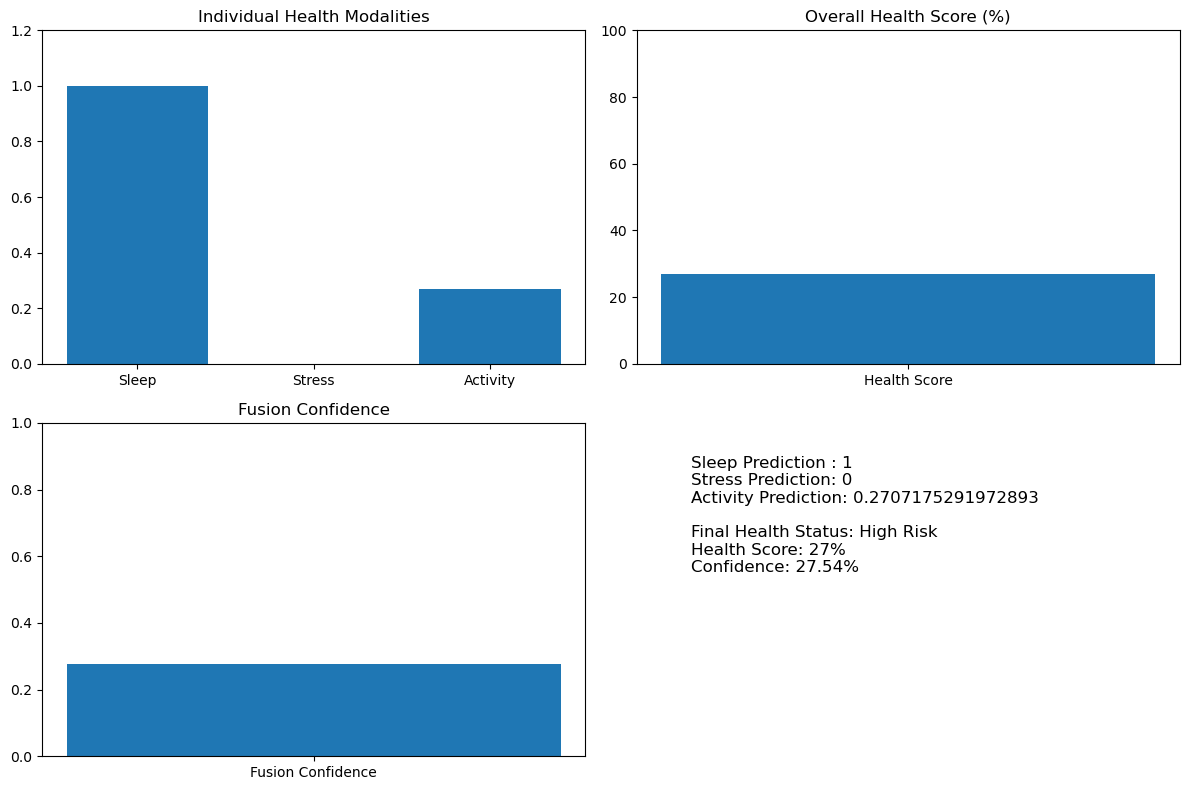

In [25]:
fig = plt.figure(figsize=(12,8))

# Modalities
plt.subplot(2,2,1)
categories = ['Sleep', 'Stress', 'Activity']
values = [sleep_pred, wesad_pred, fitbit_pred]
plt.bar(categories, values)
plt.ylim(0,1.2)
plt.title("Individual Health Modalities")

# Health Score
plt.subplot(2,2,2)
plt.bar(['Health Score'], [health_score])
plt.ylim(0,100)
plt.title("Overall Health Score (%)")

# Fusion Confidence
plt.subplot(2,2,3)
plt.bar(['Fusion Confidence'], [final_prob])
plt.ylim(0,1)
plt.title("Fusion Confidence")

# Summary
plt.subplot(2,2,4)
plt.axis('off')

summary = f"""
Sleep Prediction : {sleep_pred}
Stress Prediction: {wesad_pred}
Activity Prediction: {fitbit_pred}

Final Health Status: {'Healthy' if final_pred==1 else 'High Risk'}
Health Score: {health_score}%
Confidence: {round(final_prob*100,2)}%
"""

plt.text(0.1, 0.5, summary, fontsize=12)

plt.tight_layout()
plt.show()

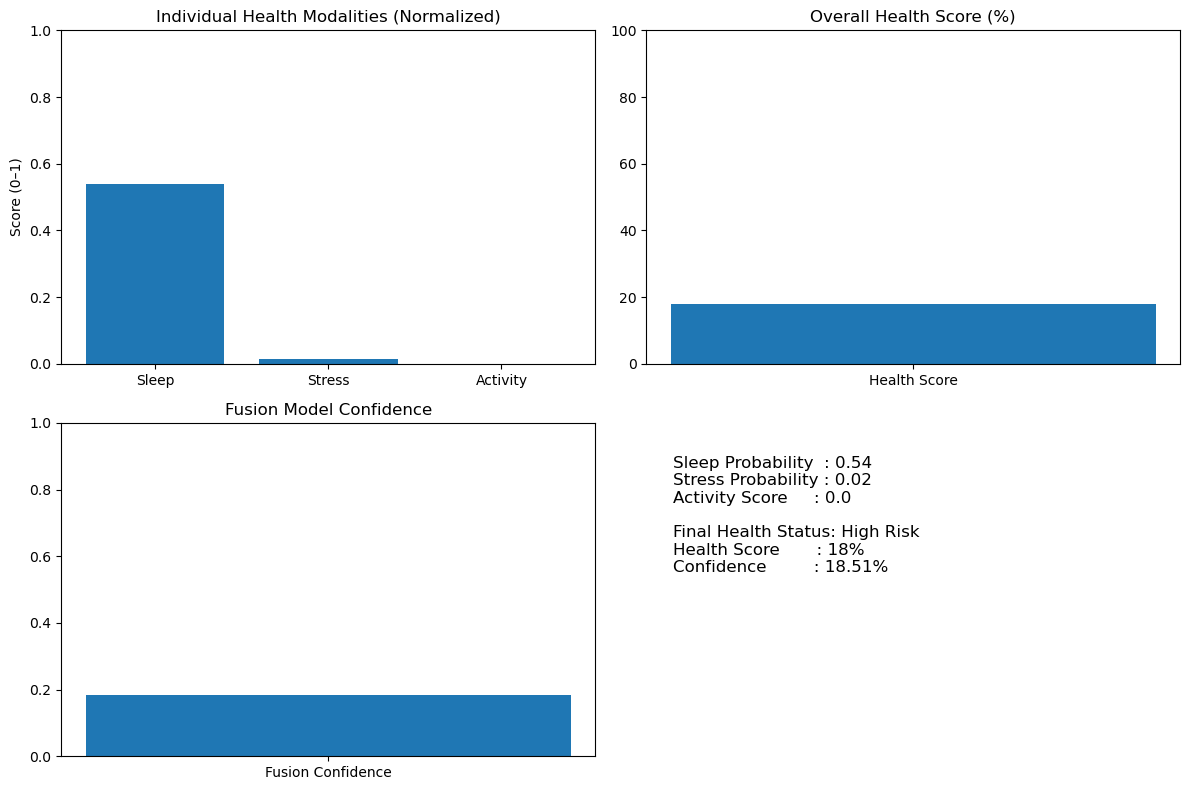

In [26]:
# Normalize Fitbit output (0–1 scale)
fitbit_norm = fitbit_output / np.max(X_fitbit)

# Final fusion probability
final_prob = (sleep_prob + wesad_prob + fitbit_norm) / 3
final_pred = 1 if final_prob > 0.5 else 0

health_score = int(final_prob * 100)

# ================= VISUALIZATION =================

fig = plt.figure(figsize=(12,8))

# 1️⃣ Individual Modalities
plt.subplot(2,2,1)
categories = ['Sleep', 'Stress', 'Activity']
values = [sleep_prob, wesad_prob, fitbit_norm]

plt.bar(categories, values)
plt.ylim(0,1)
plt.title("Individual Health Modalities (Normalized)")
plt.ylabel("Score (0–1)")

# 2️⃣ Overall Health Score
plt.subplot(2,2,2)
plt.bar(['Health Score'], [health_score])
plt.ylim(0,100)
plt.title("Overall Health Score (%)")

# 3️⃣ Fusion Confidence
plt.subplot(2,2,3)
plt.bar(['Fusion Confidence'], [final_prob])
plt.ylim(0,1)
plt.title("Fusion Model Confidence")

# 4️⃣ Summary Text
plt.subplot(2,2,4)
plt.axis('off')

summary = f"""
Sleep Probability  : {round(sleep_prob,2)}
Stress Probability : {round(wesad_prob,2)}
Activity Score     : {round(fitbit_norm,2)}

Final Health Status: {'Healthy' if final_pred==1 else 'High Risk'}
Health Score       : {health_score}%
Confidence         : {round(final_prob*100,2)}%
"""

plt.text(0.05, 0.5, summary, fontsize=12)

plt.tight_layout()
plt.show()

In [27]:
# Convert probabilities to percentage
stress_risk = int((1 - wesad_prob) * 100)
sleep_risk = int((1 - sleep_prob) * 100)
activity_risk = int((1 - fitbit_norm) * 100)

overall_index = health_score

# Classification Logic
if overall_index >= 75:
    classification = "GOOD HEALTH CONDITION"
elif overall_index >= 50:
    classification = "MODERATE HEALTH CONDITION"
else:
    classification = "HIGH RISK CONDITION"

# Function to create bar
def create_bar(value):
    bars = int(value / 10)
    return "█" * bars

print("-" * 50)
print(f"OVERALL HEALTH INDEX ({overall_index}%)")
print("[ Gauge Visualization ]")
print("-" * 50)

print(f"Stress Risk   {create_bar(stress_risk):<10} {stress_risk}%")
print(f"Sleep Risk    {create_bar(sleep_risk):<10} {sleep_risk}%")
print(f"Activity Risk {create_bar(activity_risk):<10} {activity_risk}%")

print("-" * 50)
print(f"Classification: {classification}")
print("-" * 50)

--------------------------------------------------
OVERALL HEALTH INDEX (18%)
[ Gauge Visualization ]
--------------------------------------------------
Stress Risk   █████████  98%
Sleep Risk    ████       46%
Activity Risk █████████  99%
--------------------------------------------------
Classification: HIGH RISK CONDITION
--------------------------------------------------


In [28]:
# Convert to percentage risks
stress_risk = int((1 - wesad_prob) * 100)
sleep_risk = int((1 - sleep_prob) * 100)
activity_risk = int((1 - fitbit_norm) * 100)

overall_index = health_score

# Classification
if overall_index >= 75:
    classification = "GOOD HEALTH CONDITION"
elif overall_index >= 50:
    classification = "MODERATE HEALTH CONDITION"
else:
    classification = "HIGH RISK CONDITION"

# Function to create bar
def create_bar(value):
    bars = int(value / 10)
    return "█" * bars

# ---------------- FINAL DISPLAY ---------------- #

print("\n" + "="*60)
print(f"OVERALL HEALTH INDEX ({overall_index}%)")
print("[ Multimodal Health Assessment Gauge ]")
print("-"*60)

print(f"Stress Risk   {create_bar(stress_risk):<10} {stress_risk}%")
print(f"Sleep Risk    {create_bar(sleep_risk):<10} {sleep_risk}%")
print(f"Activity Risk {create_bar(activity_risk):<10} {activity_risk}%")

print("-"*60)
print(f"Classification: {classification}")
print("-"*60)

# ---------------- RECOMMENDATIONS ---------------- #

print("\nPERSONALIZED HEALTH RECOMMENDATIONS")
print("-"*60)

if stress_risk > 70:
    print("• Stress level is critically high.")
    print("  → Practice meditation, breathing exercises, reduce workload.")

elif stress_risk > 40:
    print("• Moderate stress detected.")
    print("  → Include relaxation activities in daily routine.")

if sleep_risk > 60:
    print("• Sleep quality is poor.")
    print("  → Maintain 7–8 hours sleep and consistent sleep schedule.")

elif sleep_risk > 30:
    print("• Sleep quality is moderate.")
    print("  → Improve sleep hygiene and reduce screen time before bed.")

if activity_risk > 70:
    print("• Physical activity is very low.")
    print("  → Increase daily steps (target 7000–10000 steps).")

elif activity_risk > 40:
    print("• Activity level is moderate.")
    print("  → Include at least 30 minutes exercise daily.")

if overall_index < 40:
    print("\n⚠ Overall health risk is high.")
    print("  → Strongly consider medical consultation and lifestyle changes.")

print("="*60)


OVERALL HEALTH INDEX (18%)
[ Multimodal Health Assessment Gauge ]
------------------------------------------------------------
Stress Risk   █████████  98%
Sleep Risk    ████       46%
Activity Risk █████████  99%
------------------------------------------------------------
Classification: HIGH RISK CONDITION
------------------------------------------------------------

PERSONALIZED HEALTH RECOMMENDATIONS
------------------------------------------------------------
• Stress level is critically high.
  → Practice meditation, breathing exercises, reduce workload.
• Sleep quality is moderate.
  → Improve sleep hygiene and reduce screen time before bed.
• Physical activity is very low.
  → Increase daily steps (target 7000–10000 steps).

⚠ Overall health risk is high.
  → Strongly consider medical consultation and lifestyle changes.


In [24]:
# Convert to percentage risks
stress_risk = int((1 - wesad_prob) * 100)
sleep_risk = int((1 - sleep_prob) * 100)
activity_risk = int((1 - fitbit_norm) * 100)

overall_index = health_score

# Classification
if overall_index >= 75:
    classification = "GOOD HEALTH CONDITION"
elif overall_index >= 50:
    classification = "MODERATE HEALTH CONDITION"
else:
    classification = "HIGH RISK CONDITION"

# Function to create bar
def create_bar(value):
    bars = int(value / 10)
    return "█" * bars

# ---------------- FINAL DISPLAY ---------------- #

print("\n" + "="*60)
print(f"OVERALL HEALTH INDEX ({overall_index}%)")
print("[ Multimodal Health Assessment Gauge ]")
print("-"*60)

print(f"Stress Risk   {create_bar(stress_risk):<10} {stress_risk}%")
print(f"Sleep Risk    {create_bar(sleep_risk):<10} {sleep_risk}%")
print(f"Activity Risk {create_bar(activity_risk):<10} {activity_risk}%")

print("-"*60)
print(f"Classification: {classification}")
print("-"*60)

# ---------------- RECOMMENDATIONS ---------------- #

print("\nPERSONALIZED HEALTH RECOMMENDATIONS")
print("-"*60)

if stress_risk > 70:
    print("• Stress level is critically high.")
    print("  → Practice meditation, breathing exercises, reduce workload.")

elif stress_risk > 40:
    print("• Moderate stress detected.")
    print("  → Include relaxation activities in daily routine.")

if sleep_risk > 60:
    print("• Sleep quality is poor.")
    print("  → Maintain 7–8 hours sleep and consistent sleep schedule.")

elif sleep_risk > 30:
    print("• Sleep quality is moderate.")
    print("  → Improve sleep hygiene and reduce screen time before bed.")

if activity_risk > 70:
    print("• Physical activity is very low.")
    print("  → Increase daily steps (target 7000–10000 steps).")

elif activity_risk > 40:
    print("• Activity level is moderate.")
    print("  → Include at least 30 minutes exercise daily.")

if overall_index < 40:
    print("\n⚠ Overall health risk is high.")
    print("  → Strongly consider medical consultation and lifestyle changes.")

print("="*60)


OVERALL HEALTH INDEX (18%)
[ Multimodal Health Assessment Gauge ]
------------------------------------------------------------
Stress Risk   █████████  98%
Sleep Risk    ██         20%
Activity Risk █████████  99%
------------------------------------------------------------
Classification: HIGH RISK CONDITION
------------------------------------------------------------

PERSONALIZED HEALTH RECOMMENDATIONS
------------------------------------------------------------
• Stress level is critically high.
  → Practice meditation, breathing exercises, reduce workload.
• Physical activity is very low.
  → Increase daily steps (target 7000–10000 steps).

⚠ Overall health risk is high.
  → Strongly consider medical consultation and lifestyle changes.


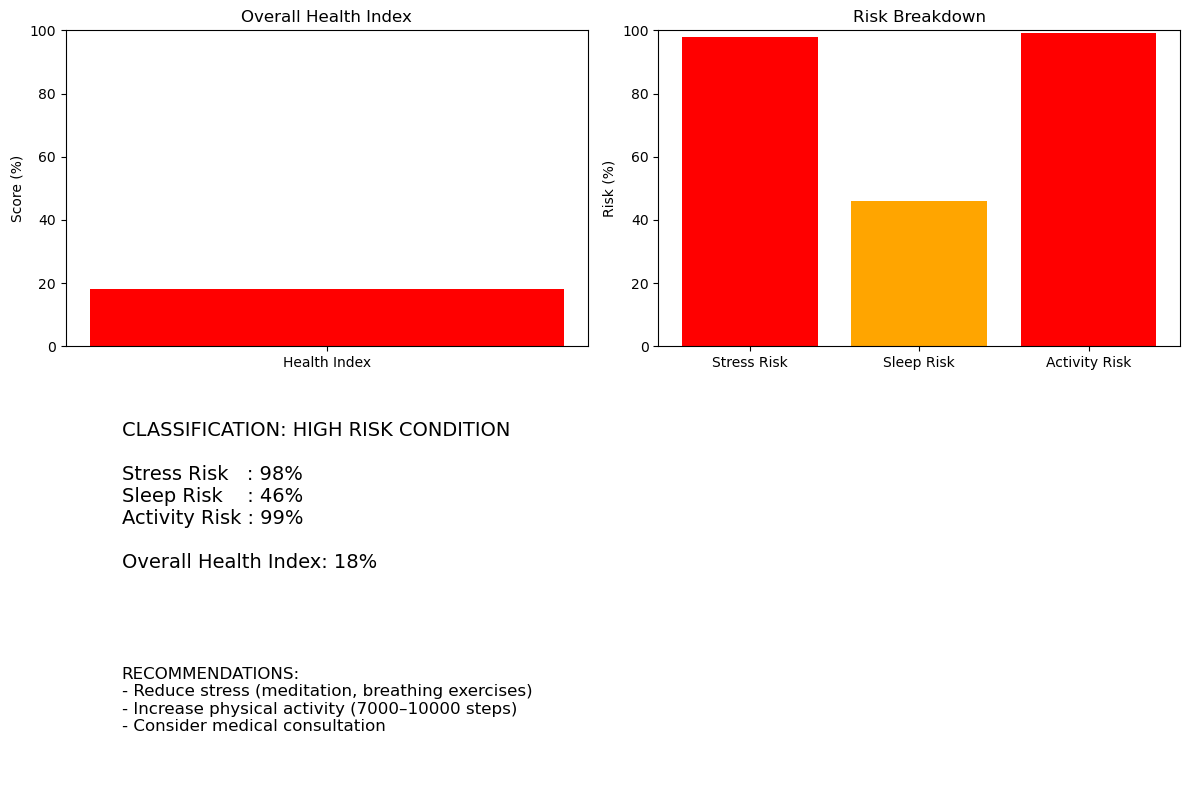

In [29]:
import matplotlib.pyplot as plt

# Convert to risks
stress_risk = int((1 - wesad_prob) * 100)
sleep_risk = int((1 - sleep_prob) * 100)
activity_risk = int((1 - fitbit_norm) * 100)
overall_index = health_score

# Classification + color
if overall_index >= 75:
    classification = "GOOD HEALTH CONDITION"
    overall_color = "green"
elif overall_index >= 50:
    classification = "MODERATE HEALTH CONDITION"
    overall_color = "orange"
else:
    classification = "HIGH RISK CONDITION"
    overall_color = "red"

# Risk colors
def get_color(value):
    if value < 40:
        return "green"
    elif value < 70:
        return "orange"
    else:
        return "red"

stress_color = get_color(stress_risk)
sleep_color = get_color(sleep_risk)
activity_color = get_color(activity_risk)

# ----------- Create Figure ----------- #

plt.figure(figsize=(12,8))

# 1️⃣ Overall Health Score
plt.subplot(2,2,1)
plt.bar(["Health Index"], [overall_index], color=overall_color)
plt.ylim(0,100)
plt.title("Overall Health Index")
plt.ylabel("Score (%)")

# 2️⃣ Risk Breakdown
plt.subplot(2,2,2)
categories = ["Stress Risk", "Sleep Risk", "Activity Risk"]
values = [stress_risk, sleep_risk, activity_risk]
colors = [stress_color, sleep_color, activity_color]

plt.bar(categories, values, color=colors)
plt.ylim(0,100)
plt.title("Risk Breakdown")
plt.ylabel("Risk (%)")

# 3️⃣ Text Summary
plt.subplot(2,1,2)
plt.axis("off")

summary_text = f"""
CLASSIFICATION: {classification}

Stress Risk   : {stress_risk}%
Sleep Risk    : {sleep_risk}%
Activity Risk : {activity_risk}%

Overall Health Index: {overall_index}%
"""

plt.text(0.05, 0.6, summary_text, fontsize=14)

# Recommendations
recommendation = "\nRECOMMENDATIONS:\n"

if stress_risk > 70:
    recommendation += "- Reduce stress (meditation, breathing exercises)\n"
if sleep_risk > 50:
    recommendation += "- Improve sleep schedule (7–8 hours)\n"
if activity_risk > 60:
    recommendation += "- Increase physical activity (7000–10000 steps)\n"
if overall_index < 40:
    recommendation += "- Consider medical consultation\n"

plt.text(0.05, 0.1, recommendation, fontsize=12)

plt.tight_layout()
plt.show()

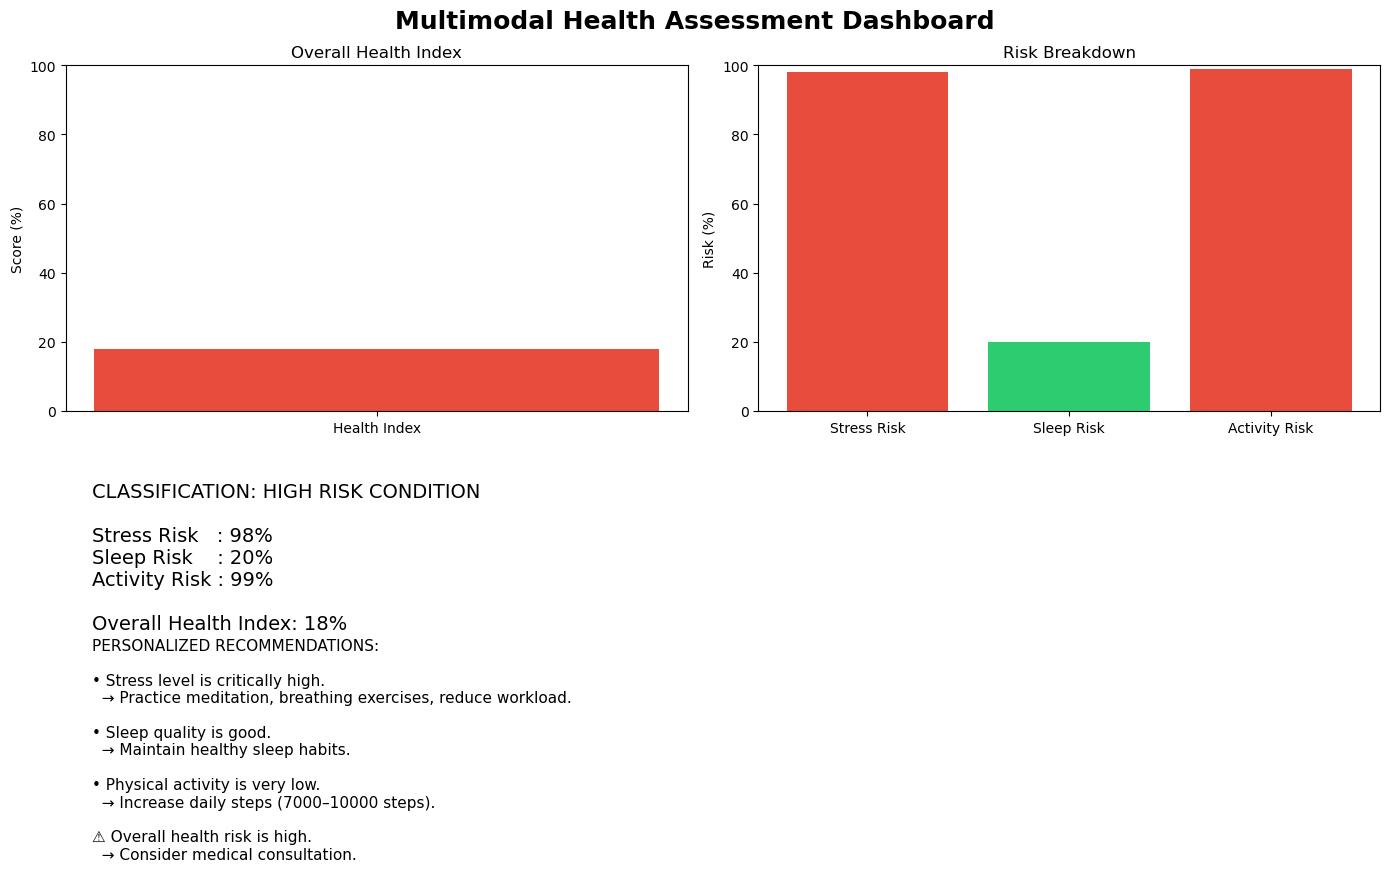

In [28]:
import matplotlib.pyplot as plt

# ---------------- Compute Risks ---------------- #

stress_risk = int((1 - wesad_prob) * 100)
sleep_risk = int((1 - sleep_prob) * 100)
activity_risk = int((1 - fitbit_norm) * 100)
overall_index = health_score

# ---------------- Classification ---------------- #

if overall_index >= 75:
    classification = "GOOD HEALTH CONDITION"
    overall_color = "#2ecc71"   # green
elif overall_index >= 50:
    classification = "MODERATE HEALTH CONDITION"
    overall_color = "#f39c12"   # orange
else:
    classification = "HIGH RISK CONDITION"
    overall_color = "#e74c3c"   # red

# Risk color function
def risk_color(value):
    if value < 40:
        return "#2ecc71"
    elif value < 70:
        return "#f39c12"
    else:
        return "#e74c3c"

stress_color = risk_color(stress_risk)
sleep_color = risk_color(sleep_risk)
activity_color = risk_color(activity_risk)

# ---------------- Create Dashboard ---------------- #

plt.figure(figsize=(14,9))
plt.suptitle("Multimodal Health Assessment Dashboard", fontsize=18, fontweight='bold')

# 1️⃣ Overall Health Index
plt.subplot(2,2,1)
plt.bar(["Health Index"], [overall_index], color=overall_color)
plt.ylim(0,100)
plt.title("Overall Health Index")
plt.ylabel("Score (%)")

# 2️⃣ Risk Breakdown
plt.subplot(2,2,2)
categories = ["Stress Risk", "Sleep Risk", "Activity Risk"]
values = [stress_risk, sleep_risk, activity_risk]
colors = [stress_color, sleep_color, activity_color]

plt.bar(categories, values, color=colors)
plt.ylim(0,100)
plt.title("Risk Breakdown")
plt.ylabel("Risk (%)")

# 3️⃣ Classification Display
plt.subplot(2,1,2)
plt.axis("off")

summary_text = f"""
CLASSIFICATION: {classification}

Stress Risk   : {stress_risk}%
Sleep Risk    : {sleep_risk}%
Activity Risk : {activity_risk}%

Overall Health Index: {overall_index}%
"""

plt.text(0.02, 0.65, summary_text, fontsize=14)

# ---------------- Recommendations ---------------- #
print()
print()
recommendation = "\nPERSONALIZED RECOMMENDATIONS:\n"

if stress_risk >= 70:
    recommendation += "\n• Stress level is critically high."
    recommendation += "\n  → Practice meditation, breathing exercises, reduce workload."
elif stress_risk >= 40:
    recommendation += "\n• Moderate stress detected."
    recommendation += "\n  → Maintain work-life balance and relaxation habits."
else:
    recommendation += "\n• Stress level is healthy."
    recommendation += "\n  → Continue current stress management practices."

if sleep_risk >= 70:
    recommendation += "\n\n• Sleep quality is poor."
    recommendation += "\n  → Maintain 7–8 hours sleep and consistent routine."
elif sleep_risk >= 40:
    recommendation += "\n\n• Sleep quality is moderate."
    recommendation += "\n  → Improve sleep hygiene and reduce screen time."
else:
    recommendation += "\n\n• Sleep quality is good."
    recommendation += "\n  → Maintain healthy sleep habits."

if activity_risk >= 70:
    recommendation += "\n\n• Physical activity is very low."
    recommendation += "\n  → Increase daily steps (7000–10000 steps)."
elif activity_risk >= 40:
    recommendation += "\n\n• Activity level is moderate."
    recommendation += "\n  → Add 30 minutes exercise daily."
else:
    recommendation += "\n\n• Physical activity level is good."
    recommendation += "\n  → Maintain active lifestyle."

if overall_index < 40:
    recommendation += "\n\n⚠ Overall health risk is high."
    recommendation += "\n  → Consider medical consultation."
elif overall_index < 70:
    recommendation += "\n\n⚠ Overall health is moderate."
    recommendation += "\n  → Lifestyle improvements recommended."
else:
    recommendation += "\n\n✓ Overall health is good."
    recommendation += "\n  → Continue maintaining healthy habits."

plt.text(0.02, 0.05, recommendation, fontsize=11)

plt.tight_layout()
plt.show()

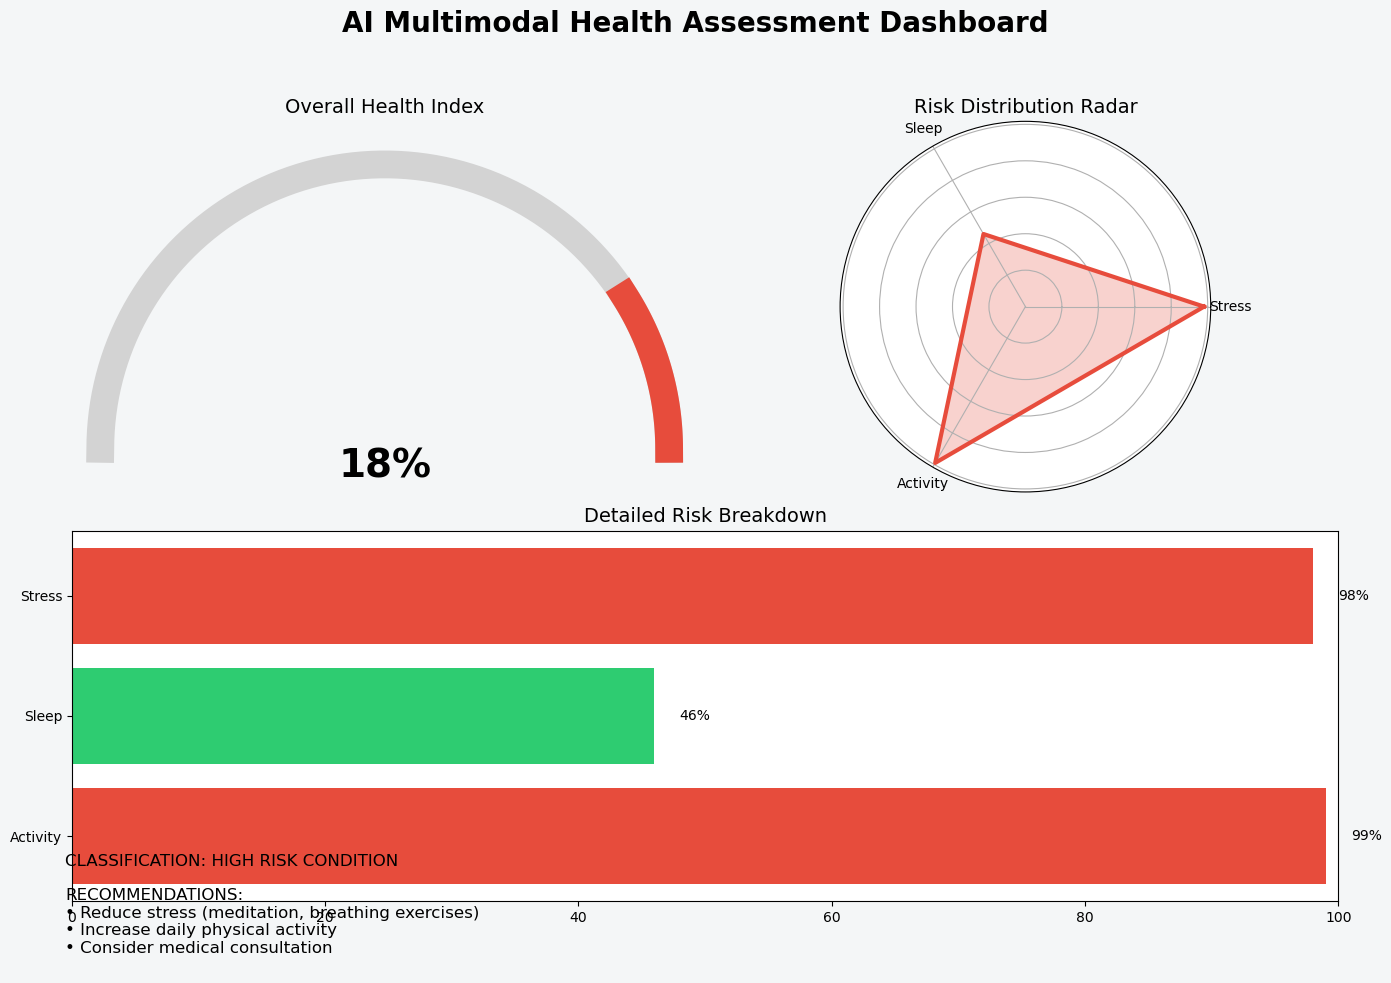

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------- Compute Risks ---------------- #

stress_risk = int((1 - wesad_prob) * 100)
sleep_risk = int((1 - sleep_prob) * 100)
activity_risk = int((1 - fitbit_norm) * 100)
overall_index = health_score

# ---------------- Classification ---------------- #

if overall_index >= 75:
    classification = "GOOD HEALTH CONDITION"
    main_color = "#2ecc71"
elif overall_index >= 50:
    classification = "MODERATE HEALTH CONDITION"
    main_color = "#f39c12"
else:
    classification = "HIGH RISK CONDITION"
    main_color = "#e74c3c"

# ---------------- Create Figure ---------------- #

fig = plt.figure(figsize=(14,10))
fig.patch.set_facecolor('#f4f6f7')
plt.suptitle("AI Multimodal Health Assessment Dashboard", 
             fontsize=20, fontweight='bold')

# =====================================================
# 1️⃣ Circular Gauge (Health Index)
# =====================================================

ax1 = plt.subplot(2,2,1)
ax1.axis('equal')

theta = np.linspace(0, np.pi, 100)
r = np.ones(100)

ax1.plot(r*np.cos(theta), r*np.sin(theta), color='lightgray', linewidth=20)
theta_fill = np.linspace(0, np.pi*(overall_index/100), 100)
ax1.plot(r[:100]*np.cos(theta_fill), 
         r[:100]*np.sin(theta_fill), 
         color=main_color, linewidth=20)

ax1.text(0, -0.1, f"{overall_index}%", 
         fontsize=28, ha='center', fontweight='bold')

ax1.set_title("Overall Health Index", fontsize=14)
ax1.axis('off')

# =====================================================
# 2️⃣ Radar Chart (Risk Distribution)
# =====================================================

ax2 = plt.subplot(2,2,2, polar=True)

categories = ['Stress', 'Sleep', 'Activity']
values = [stress_risk, sleep_risk, activity_risk]
values += values[:1]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

ax2.plot(angles, values, linewidth=3, color=main_color)
ax2.fill(angles, values, alpha=0.25, color=main_color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)
ax2.set_yticklabels([])
ax2.set_title("Risk Distribution Radar", fontsize=14)

# =====================================================
# 3️⃣ Risk Bars (Clean Design)
# =====================================================

ax3 = plt.subplot(2,1,2)
ax3.set_facecolor("#ffffff")

bars = ax3.barh(categories, 
                [stress_risk, sleep_risk, activity_risk],
                color=[ "#e74c3c" if stress_risk>70 else "#2ecc71",
                        "#e74c3c" if sleep_risk>70 else "#2ecc71",
                        "#e74c3c" if activity_risk>70 else "#2ecc71"])

ax3.set_xlim(0,100)
ax3.set_title("Detailed Risk Breakdown", fontsize=14)
ax3.invert_yaxis()

for i, v in enumerate([stress_risk, sleep_risk, activity_risk]):
    ax3.text(v + 2, i, f"{v}%", va='center')

# =====================================================
# 4️⃣ Text Panel (Classification + Recommendations)
# =====================================================

recommendation = ""

if stress_risk > 70:
    recommendation += "• Reduce stress (meditation, breathing exercises)\n"
if sleep_risk > 50:
    recommendation += "• Improve sleep schedule (7–8 hours daily)\n"
if activity_risk > 60:
    recommendation += "• Increase daily physical activity\n"
if overall_index < 40:
    recommendation += "• Consider medical consultation\n"

fig.text(0.05, 0.02,
         f"CLASSIFICATION: {classification}\n\nRECOMMENDATIONS:\n{recommendation}",
         fontsize=12)

plt.tight_layout(rect=[0,0.05,1,0.95])
plt.show()